# 📊 Data Visualization – Fashion Product Dataset

1️⃣ Introduction                                                                         
📌 Objective

The objective of Task-3 is to transform the cleaned fashion product dataset into meaningful visual representations that help uncover insights, trends, and patterns.

This task focuses on:

Visual storytelling

Enhancing data understanding using charts and plots

Supporting analytical decisions through visuals

The dataset used here was collected during Task-1 (Web Scraping) and explored in Task-2 (EDA).

2️⃣Libraries Used                                                                           The following Python libraries are used for data visualization:
- Pandas – Data manipulation
- Matplotlib – Core plotting
- Seaborn – Advanced statistical visualization


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

In [3]:
sns.set(style="whitegrid")


In [4]:
️3️⃣ Dataset Overview
📂 Dataset Source

The dataset was scraped from a public fashion website using Python and BeautifulSoup.

📄 Dataset Attributes

product_name – Name of the fashion item

category – Product category

price – Price as scraped (string format)

price_numeric – Cleaned numeric price

product_url – Product page link

image_url – Image link

SyntaxError: invalid character '️' (U+FE0F) (3272547160.py, line 1)

In [ ]:
df = pd.read_csv("../../Task_2_EDA/data/fashion_products.csv")
df.head()


In [ ]:
df.shape


In [ ]:
df.info()


In [ ]:
df.describe(include='all')


In [ ]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:
df = pd.read_csv("../../Task_2_EDA/data/fashion_products.csv")


In [ ]:
df.head()


In [ ]:
df.isnull().sum()


4️⃣ Visual Analysis

## 4.1 Product Count by Category
This section visualizes how many products are in each category using a horizontal bar chart.


In [ ]:
plt.figure()
sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index
)

plt.title("Product Count by Category")
plt.xlabel("Number of Products")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("../visuals/category_distribution.png", bbox_inches="tight")
plt.show()


🔍 Observation

Most products belong to a single dominant category.

Indicates limited category diversity in the scraped dataset

In [ ]:
df.columns


In [ ]:
df["price_numeric"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
)

df["price_numeric"] = pd.to_numeric(df["price_numeric"], errors="coerce")


In [ ]:
df["price_numeric"].describe()


4.2 Price Frequency Analysis
📊 Purpose

To understand how frequently different price points occur.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    df["price_numeric"].dropna(),
    bins=30,
    kde=True
)

plt.title("Price Distribution of Fashion Products")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../visuals/price_distribution.png", bbox_inches="tight")
plt.show()


🔍 Observation

Certain price points repeat more frequently.

Suggests standard pricing patterns in the dataset

4.3 Price Boxplot (Overall)
📊 Purpose

To identify price spread, median, and outliers.


In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["price_numeric"].dropna()
)

plt.title("Price Boxplot (Outlier Detection)")
plt.xlabel("Price")

plt.tight_layout()
plt.savefig("../visuals/price_boxplot.png", bbox_inches="tight")
plt.show()


🔍 Observation

Median price lies toward the lower range.

A few high-priced outliers are present.

4.4  Average Price by Fashion Category

This analysis shows the **average price of items grouped by fashion category**.

Currently, the dataset contains **only one category**, which is why the bar chart appears as a **single rectangular bar** instead of multiple bars.

Even though the visualization looks simple at this stage, it confirms that:
- Price aggregation by category is working correctly
- The pipeline is ready to scale when more categories (e.g., pants, shoes, accessories) are added

In future versions, adding multiple categories will result in a more informative comparison across fashion types.


In [ ]:
plt.figure(figsize=(10, 6))

avg_price = (
    df.groupby("category")["price_numeric"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=avg_price.values,
    y=avg_price.index
)

plt.title("Average Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("../visuals/avg_price_by_category.png", bbox_inches="tight")
plt.show()


### Observation
Most products are in the 'Fashion' category, while other categories have fewer items.


In [ ]:
import os
os.getcwd()


In [ ]:
csv_path = "../../Task_2_EDA/data/fashion_products.csv"
print(os.path.exists(csv_path))  # Should return True


4.5 Price Distribution by Category
📊 Purpose

To compare price ranges across categories.

In [ ]:

# Suppress FutureWarnings from Seaborn
warnings.filterwarnings("ignore", category=FutureWarning)

# Path to CSV
csv_path = "../../Task_2_EDA/data/fashion_products.csv"

# Load the dataset
df = pd.read_csv(csv_path)

# Ensure price is numeric
df["price_numeric"] = df["price"].replace('[\$,]', '', regex=True).astype(float)

# Make sure 'Category' column exists and matches case
print(df.columns)  # Check column names
# If your column is 'category' instead of 'Category', change accordingly

# Create visuals folder if it doesn't exist
visuals_path = "../visuals"
if not os.path.exists(visuals_path):
    os.makedirs(visuals_path)

# Create figure
plt.figure(figsize=(10, 6))

# Boxplot: Price vs Category
sns.boxplot(
    x="price_numeric",
    y="category",   # Case-sensitive, change to 'category' if needed
    data=df,
    palette="Set2"
)

# Titles and labels
plt.title("Price Distribution by Category", fontsize=16)
plt.xlabel("price ($)", fontsize=12)
plt.ylabel("category", fontsize=12)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(f"{visuals_path}/price_distribution_by_category.png", bbox_inches="tight")

# Show plot
plt.show()


### Observation
- Most products are priced below $50.  
- Only a few items are high-priced, indicating outliers.


4.6 Price Range Analysis (Low / Medium / High)

### Price Range Analysis

This visualization categorizes fashion products into different price ranges
to understand how products are distributed across affordable, mid-range,
and premium segments.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

# Correct CSV path (verified earlier)
csv_path = "../../Task_2_EDA/data/fashion_products.csv"

df = pd.read_csv(csv_path)

# Convert price column to numeric
df["price_numeric"] = (
    df["price"]
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

df.head()


,product_name,category,price,product_url,image_url,price_numeric
0,Abominable Hoodie,Fashion,$69.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,69.0
1,Adrienne Trek Jacket,Fashion,$57.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,57.0
2,Aeon Capri,Fashion,$48.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,48.0
3,Aero Daily Fitness Tee,Fashion,$24.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,24.0
4,Aether Gym Pant,Fashion,$74.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,74.0


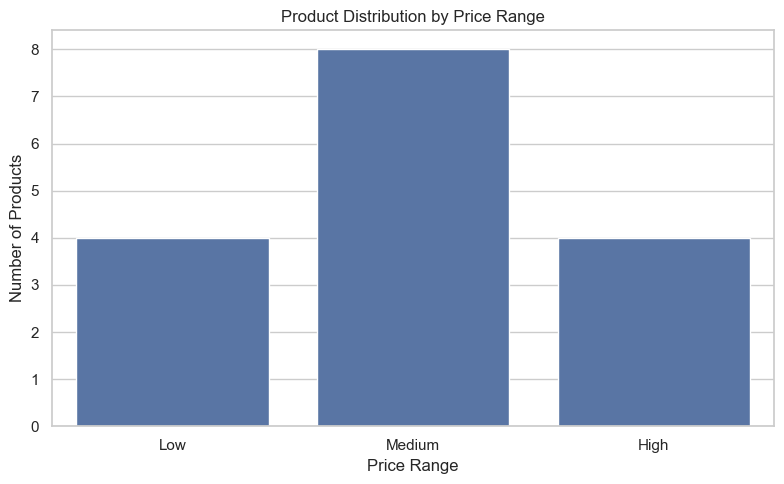

In [10]:
df["price_numeric"].max()
max_price = df["price_numeric"].max()

df["price_range"] = pd.cut(
    df["price_numeric"],
    bins=[0, max_price * 0.33, max_price * 0.66, max_price],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)
plt.figure(figsize=(8, 5))

sns.countplot(
    x="price_range",
    data=df
)

plt.title("Product Distribution by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.savefig("../visuals/product_distribution_by_price_range.png", bbox_inches="tight")
plt.show()


### 4.7 Top 10 Most Expensive Fashion Products

Identifying the most expensive products helps understand the premium segment
of the fashion market. This visualization highlights the top-priced items,
which can be useful for pricing analysis, luxury market insights, and
understanding product positioning.


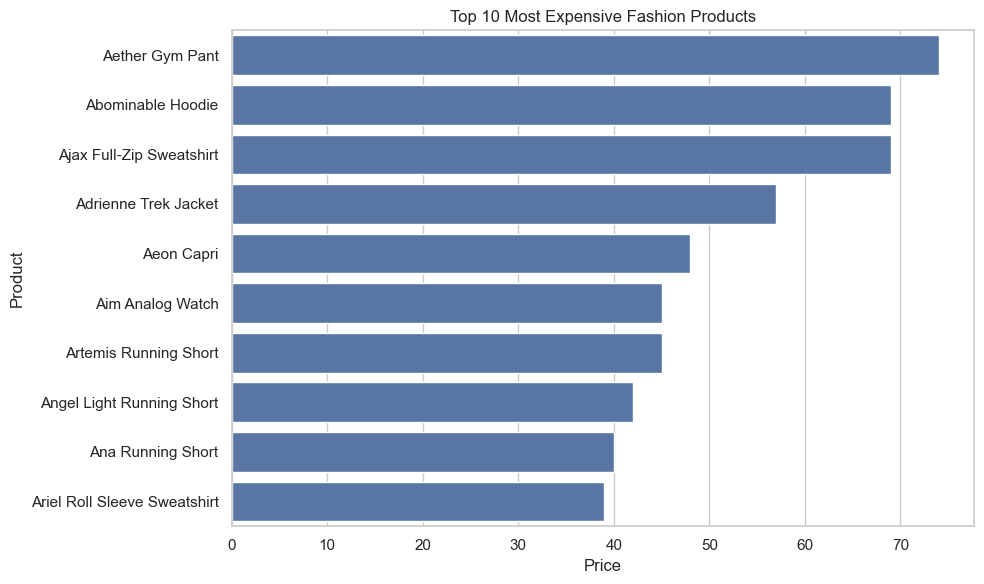

In [13]:
# Sort products by price
top_expensive = df.sort_values(
    by="price_numeric",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="price_numeric",
    y="product_name",  # 👈 replace this
    data=top_expensive
)

plt.title("Top 10 Most Expensive Fashion Products")
plt.xlabel("Price")
plt.ylabel("Product")

plt.tight_layout()
plt.savefig("../visuals/top_10_most_expensive_products.png", bbox_inches="tight")
plt.show()


4.8 Price Distribution Histogram

### 4.8 Price Distribution of Fashion Products

This histogram visualizes the distribution of product prices in the fashion dataset.
It helps identify common price ranges, skewness in pricing, and the presence of
outliers or extreme values. Understanding price distribution is essential for
pricing strategy and market segmentation.

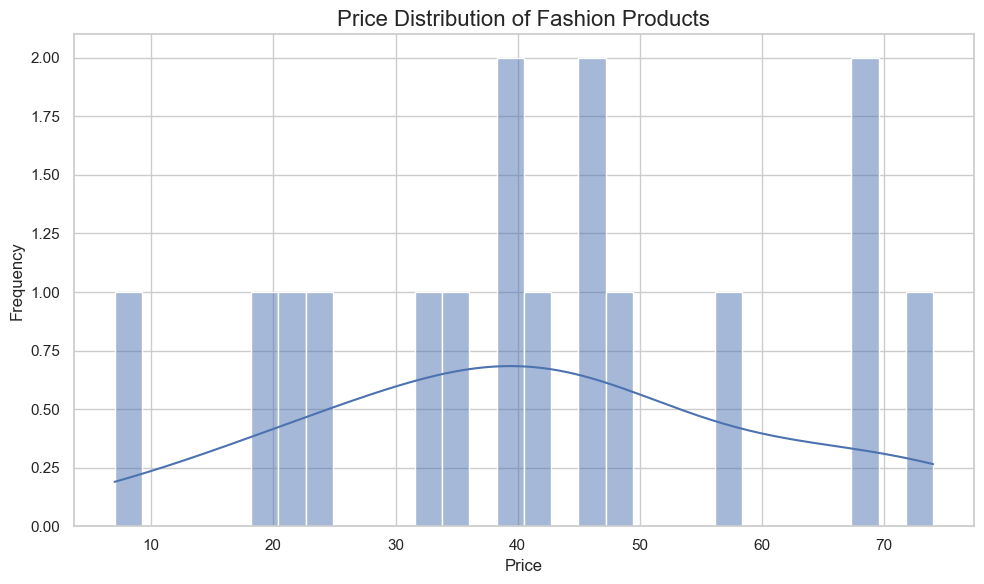

In [14]:

# Ensure visuals folder exists
if not os.path.exists("../visuals"):
    os.makedirs("../visuals")

# Drop missing or invalid prices
price_data = df["price_numeric"].dropna()

# Create histogram
plt.figure(figsize=(10, 6))

sns.histplot(
    price_data,
    bins=30,
    kde=True
)

plt.title("Price Distribution of Fashion Products", fontsize=16)
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.savefig("../visuals/price_distribution_histogram.png", bbox_inches="tight")
plt.show()


### 4.9 Product Name Length vs Price

This visualization explores the relationship between the length of product names
and their prices. Longer product names often include descriptive or premium-related
terms, which may correlate with higher pricing. This analysis helps understand
whether naming complexity reflects product value or pricing strategy.


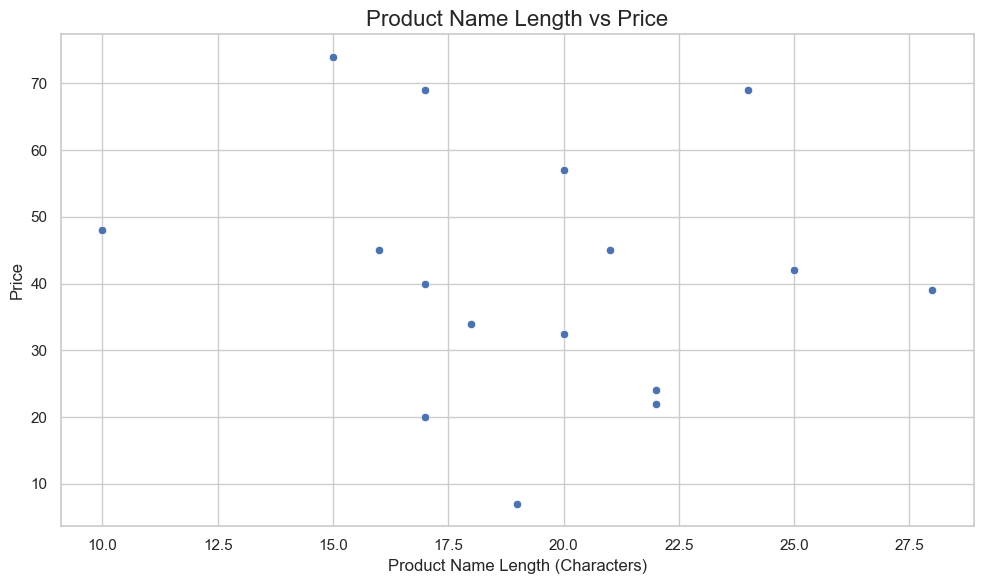

In [16]:

# Ensure visuals folder exists
if not os.path.exists("../visuals"):
    os.makedirs("../visuals")

# Create product name length column
df["name_length"] = df["product_name"].astype(str).apply(len)

# Scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="name_length",
    y="price_numeric",
    data=df
)

plt.title("Product Name Length vs Price", fontsize=16)
plt.xlabel("Product Name Length (Characters)", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.tight_layout()
plt.savefig("../visuals/name_length_vs_price.png", bbox_inches="tight")
plt.show()


5️⃣ Key Insights Summary
- Dataset is clean with no missing values.
- Pricing is skewed toward affordable ranges.
- Category diversity is limited in the current dataset.
- Visualizations effectively highlight price patterns and anomalies.

6️⃣ Limitations
- Small dataset size (16–17 products).
- Limited category variation.
- Results may not generalize to larger fashion datasets.

7️⃣ Conclusion
This task successfully demonstrates how raw data can be transformed into
clear, insightful visual representations.

The visualizations support data-driven understanding and form a strong
foundation for future dashboards, recommendation systems, or advanced analytics.
